In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("archive/temperature-medie-annuali-1950-2024.csv")

df.head()

,country,year,iso_code,mean_temperature
0,Afghanistan,1950,AFG,11.41
1,Afghanistan,1951,AFG,12.25
2,Afghanistan,1952,AFG,12.39
3,Afghanistan,1953,AFG,12.74
4,Afghanistan,1954,AFG,12.05


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14700 entries, 0 to 14699
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           14700 non-null  object 
 1   year              14700 non-null  int64  
 2   iso_code          14700 non-null  object 
 3   mean_temperature  14700 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 459.5+ KB


In [4]:
df.describe()

,year,mean_temperature
count,14700.000000,14700.000000
mean,1987.000000,19.161914
std,21.649447,8.184091
min,1950.000000,-6.790000
25%,1968.000000,11.450000
50%,1987.000000,22.580000
75%,2006.000000,25.870000
max,2024.000000,30.020000


In [5]:
df.isnull().sum()

country             0
year                0
iso_code            0
mean_temperature    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
global_avg = df.groupby("year")["mean_temperature"].mean().reset_index()

global_avg.head()

,year,mean_temperature
0,1950,18.686633
1,1951,18.864286
2,1952,18.829439
3,1953,18.863367
4,1954,18.590816


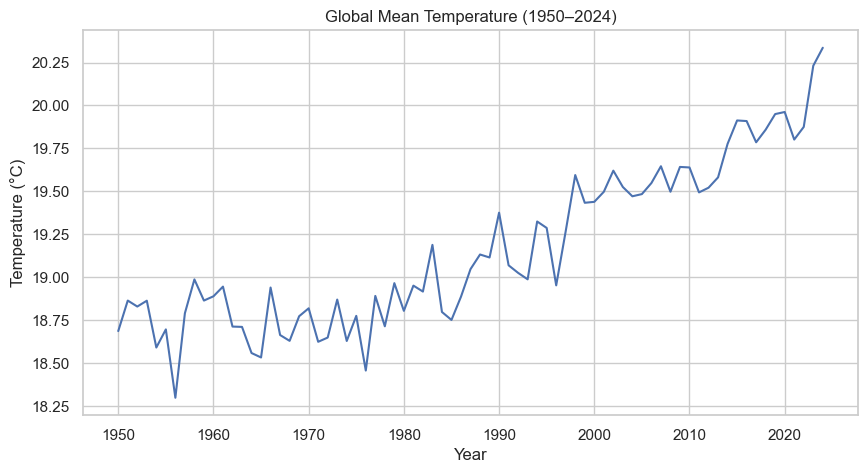

In [8]:
plt.figure(figsize=(10,5))
plt.plot(global_avg["year"], global_avg["mean_temperature"])
plt.title("Global Mean Temperature (1950–2024)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

In [9]:
baseline = df[(df["year"] >= 1950) & (df["year"] <= 1980)]

baseline_avg = baseline.groupby("country")["mean_temperature"].mean()

df["baseline_temp"] = df["country"].map(baseline_avg)

df["temp_change"] = df["mean_temperature"] - df["baseline_temp"]

df.head()

,country,year,iso_code,mean_temperature,baseline_temp,temp_change
0,Afghanistan,1950,AFG,11.41,12.422903,-1.012903
1,Afghanistan,1951,AFG,12.25,12.422903,-0.172903
2,Afghanistan,1952,AFG,12.39,12.422903,-0.032903
3,Afghanistan,1953,AFG,12.74,12.422903,0.317097
4,Afghanistan,1954,AFG,12.05,12.422903,-0.372903


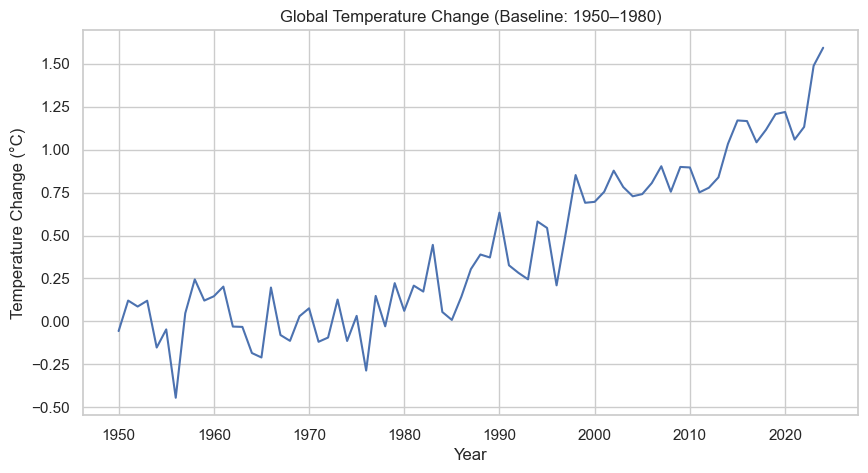

In [10]:
global_change = df.groupby("year")["temp_change"].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(global_change["year"], global_change["temp_change"])
plt.title("Global Temperature Change (Baseline: 1950–1980)")
plt.xlabel("Year")
plt.ylabel("Temperature Change (°C)")
plt.show()

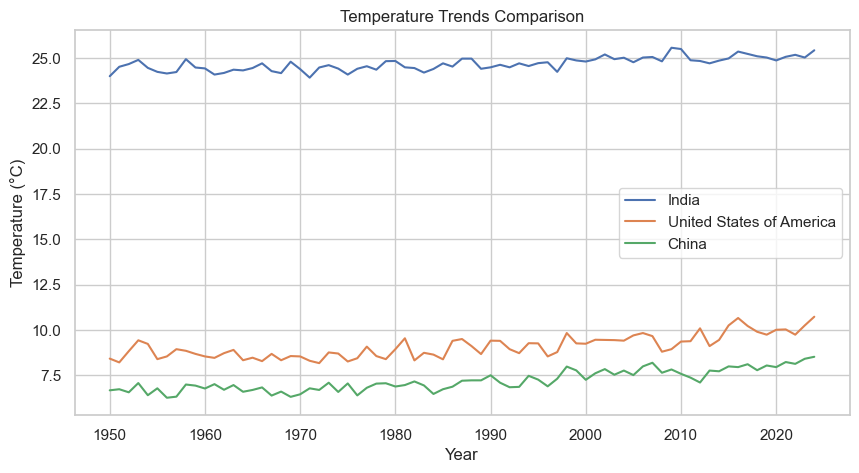

In [12]:
countries = ["India", "United States of America", "China"]

subset = df[df["country"].isin(countries)]

plt.figure(figsize=(10,5))

for c in countries:
    temp = subset[subset["country"] == c]
    plt.plot(temp["year"], temp["mean_temperature"], label=c)

plt.legend()
plt.title("Temperature Trends Comparison")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

In [13]:
latest_year = df["year"].max()

latest_data = df[df["year"] == latest_year]

top10 = latest_data.sort_values(by="mean_temperature", ascending=False).head(10)

top10[["country", "mean_temperature"]]

,country,mean_temperature
1124,Burkina Faso,29.94
8699,Mali,29.69
11399,Senegal,29.41
9149,Mauritania,29.25
3449,Djibouti,29.22
4949,The Gambia,28.84
10949,Qatar,28.70
8549,Marshall Islands,28.62
374,United Arab Emirates,28.62
1049,Benin,28.57


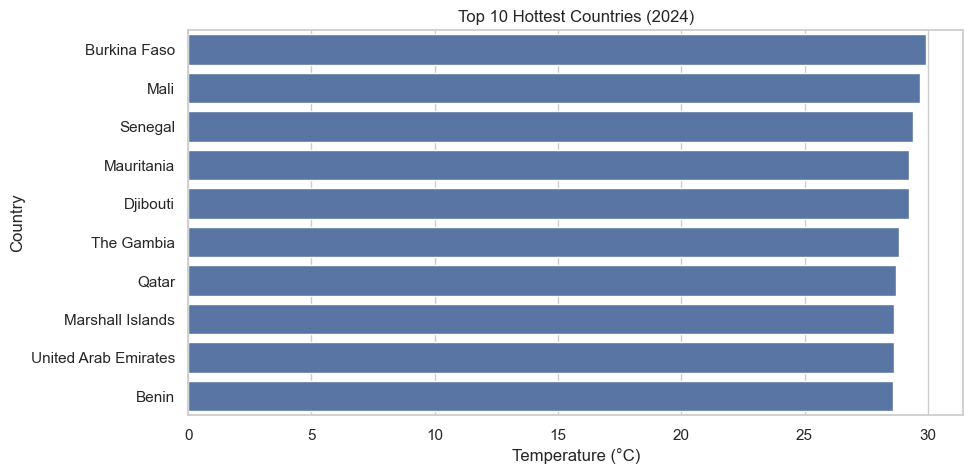

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(x="mean_temperature", y="country", data=top10)
plt.title(f"Top 10 Hottest Countries ({latest_year})")
plt.xlabel("Temperature (°C)")
plt.ylabel("Country")
plt.show()

In [15]:
change_by_country = df.groupby("country")["temp_change"].mean().reset_index()

top_warming = change_by_country.sort_values(by="temp_change", ascending=False).head(10)

top_warming

,country,temp_change
143,Russian Federation,0.789880
113,Mongolia,0.778439
86,Kazakhstan,0.745265
15,Belarus,0.740529
161,South Sudan,0.739647
190,Uzbekistan,0.734348
91,Kyrgyz Republic,0.728391
93,Latvia,0.728280
99,Lithuania,0.719927
98,Liechtenstein,0.695458


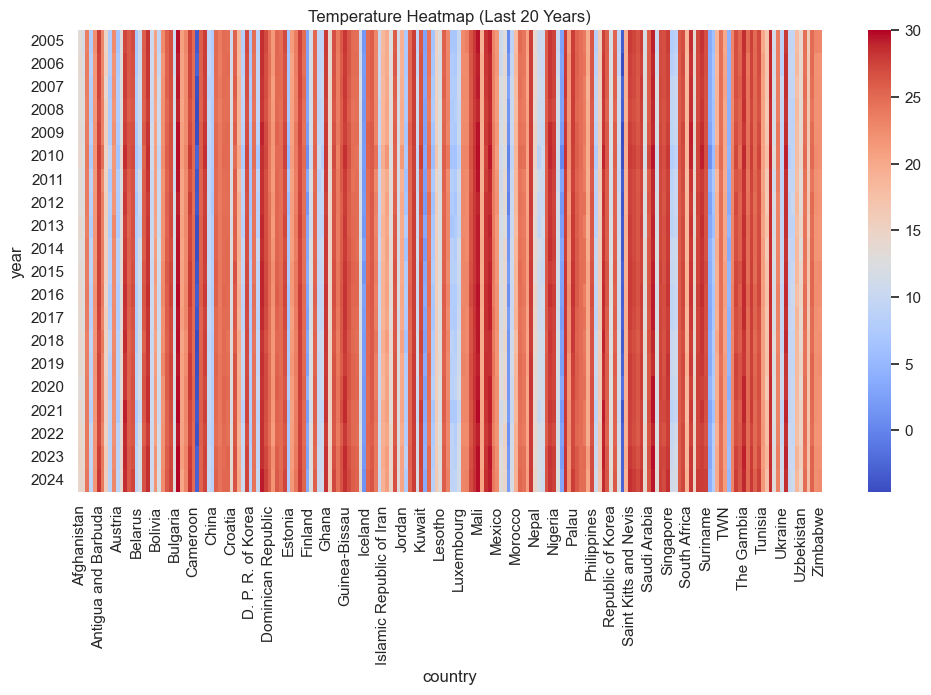

In [16]:
pivot = df.pivot_table(values="mean_temperature", index="year", columns="country")

plt.figure(figsize=(12,6))
sns.heatmap(pivot.iloc[-20:], cmap="coolwarm")
plt.title("Temperature Heatmap (Last 20 Years)")
plt.show()

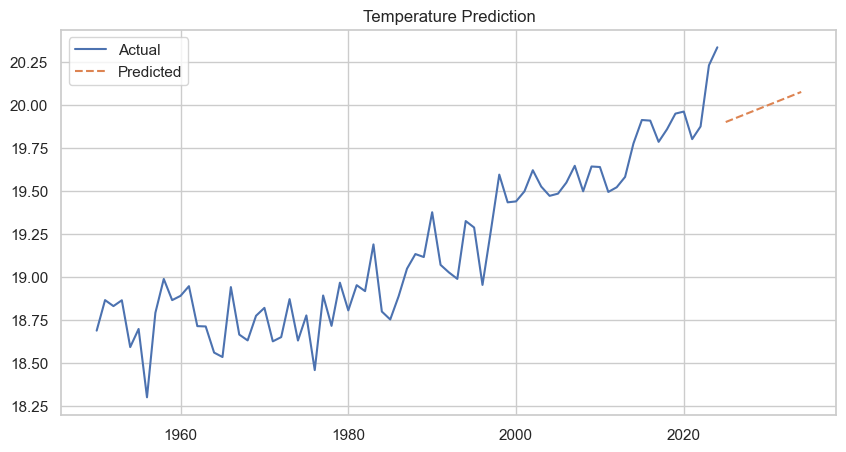

In [18]:

X = global_avg["year"].values.reshape(-1,1)
y = global_avg["mean_temperature"].values

model = LinearRegression()
model.fit(X, y)

future_years = np.array(range(2025, 2035)).reshape(-1,1)
predictions = model.predict(future_years)

plt.figure(figsize=(10,5))
plt.plot(global_avg["year"], y, label="Actual")
plt.plot(future_years, predictions, linestyle="dashed", label="Predicted")
plt.legend()
plt.title("Temperature Prediction")
plt.show()

In [20]:
latest_year = df["year"].max()

map_df = df[df["year"] == latest_year]

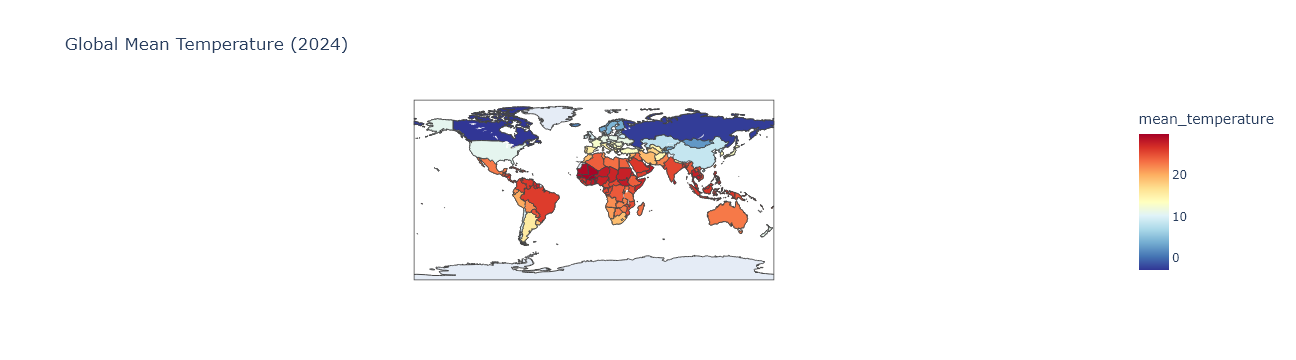

In [21]:
fig = px.choropleth(
    map_df,
    locations="iso_code",          # ISO country codes
    color="mean_temperature",
    hover_name="country",
    color_continuous_scale="RdYlBu_r",
    title=f"Global Mean Temperature ({latest_year})"
)

fig.show()

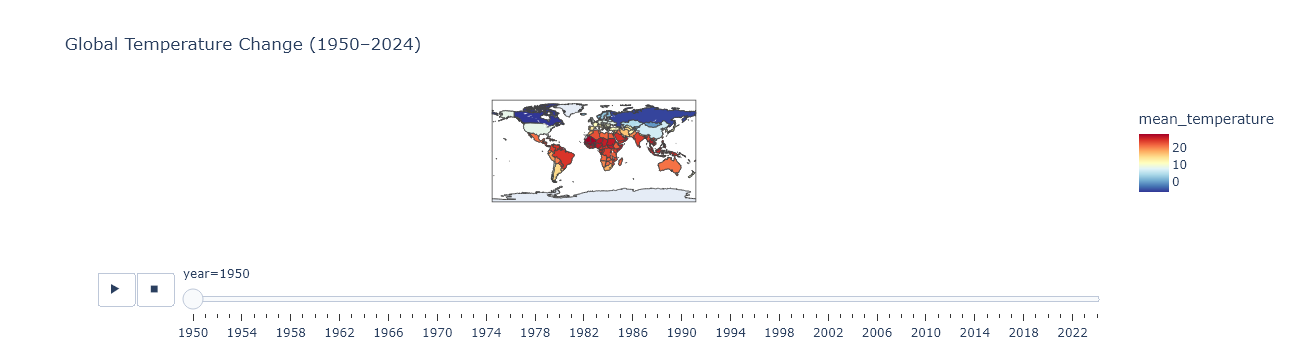

In [22]:
fig = px.choropleth(
    df,
    locations="iso_code",
    color="mean_temperature",
    hover_name="country",
    animation_frame="year",
    color_continuous_scale="RdYlBu_r",
    title="Global Temperature Change (1950–2024)"
)

fig.show()

In [25]:
baseline = df[(df["year"] >= 1950) & (df["year"] <= 1980)]
baseline_avg = baseline.groupby("country")["mean_temperature"].mean()

df["baseline_temp"] = df["country"].map(baseline_avg)
df["temp_change"] = df["mean_temperature"] - df["baseline_temp"]

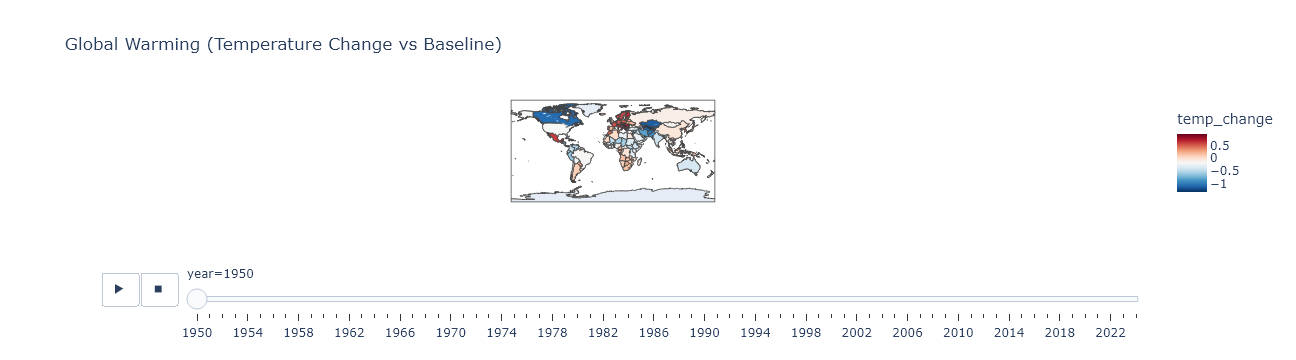

In [26]:
fig = px.choropleth(
    df,
    locations="iso_code",
    color="temp_change",
    hover_name="country",
    animation_frame="year",
    color_continuous_scale="RdBu_r",
    title="Global Warming (Temperature Change vs Baseline)"
)

fig.show()